In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Let's first filter the data using suggested in the instructions and run some EDA

In [13]:
# Constants
DATA = '../data'
FIGS = '../figs'
OUT = '../out'

In [ ]:
# Columns to use in analysis
columns_to_use = [
    'ID', 
    'ran_in_way_pipeline', 
    'ClusterK2_kmeans',
    'ClusterK3_kmeans',
    'ClusterK4_kmeans',  
    'ClusterK2_NMF', 
    'ClusterK3_NMF', 
    'ClusterK4_NMF', 
    'ClusterK4_kmeans_TCGA_names', 
    'external_HGSCsubtype_estimate'
    ]

# load main_black_metadata and filter by ran_in_way_pipeline
main_black_md = pd.read_csv(f'{DATA}/supp_table_3_main_black_metadata_table.tsv', header=0, sep='\t', usecols=columns_to_use)
main_black_md = main_black_md[main_black_md['ran_in_way_pipeline'] == True] # filtering as bool since we have only True and nan

# load main_white_metadata and filter by ran_in_way_pipeline
main_white_md = pd.read_csv(f'{DATA}/supp_table_4_main_white_metadata_table.tsv', header=0, sep='\t',usecols=columns_to_use)
main_white_md = main_white_md[main_white_md['ran_in_way_pipeline'] == True]

In [15]:
main_black_md.head()

,ID,ran_in_way_pipeline,ClusterK2_kmeans,ClusterK3_kmeans,ClusterK4_kmeans,ClusterK2_NMF,ClusterK3_NMF,ClusterK4_NMF,ClusterK4_kmeans_TCGA_names,external_HGSCsubtype_estimate
0,19291X1,True,1.0,1.0,1.0,1.0,1.0,1.0,Mesenchymal,NaN
1,19291X2,True,1.0,1.0,1.0,1.0,1.0,1.0,Mesenchymal,NaN
3,19291X3,True,2.0,2.0,2.0,1.0,2.0,2.0,Proliferative,NaN
4,19291X4,True,1.0,1.0,1.0,1.0,2.0,2.0,Mesenchymal,NaN
5,19291X5,True,2.0,3.0,3.0,2.0,3.0,3.0,Immunoreactive,NaN


In [16]:
main_white_md.head()

,ID,ran_in_way_pipeline,ClusterK2_kmeans,ClusterK3_kmeans,ClusterK4_kmeans,ClusterK2_NMF,ClusterK3_NMF,ClusterK4_NMF,ClusterK4_kmeans_TCGA_names,external_HGSCsubtype_estimate
0,20160X108,True,1.0,1.0,1.0,1.0,3.0,3.0,Mesenchymal,NaN
1,20160X247,True,1.0,2.0,2.0,2.0,2.0,2.0,Proliferative,NaN
2,20160X248,True,1.0,2.0,4.0,2.0,2.0,4.0,Differentiated,NaN
3,20160X284,True,1.0,1.0,1.0,1.0,3.0,3.0,Mesenchymal,NaN
4,20160X221,True,1.0,1.0,1.0,2.0,3.0,3.0,Mesenchymal,NaN


### Let's see if we have any missing data

In [17]:
main_black_md.isna().sum()

ID                                 0
ran_in_way_pipeline                0
ClusterK2_kmeans                   0
ClusterK3_kmeans                   0
ClusterK4_kmeans                   0
ClusterK2_NMF                      0
ClusterK3_NMF                      0
ClusterK4_NMF                      0
ClusterK4_kmeans_TCGA_names        0
external_HGSCsubtype_estimate    242
dtype: int64

In [18]:
main_white_md.isna().sum()

ID                                 0
ran_in_way_pipeline                0
ClusterK2_kmeans                   0
ClusterK3_kmeans                   0
ClusterK4_kmeans                   0
ClusterK2_NMF                      0
ClusterK3_NMF                      0
ClusterK4_NMF                      0
ClusterK4_kmeans_TCGA_names        0
external_HGSCsubtype_estimate    289
dtype: int64

## Let's compare K4 clustering agreement between Kmeans and NMf

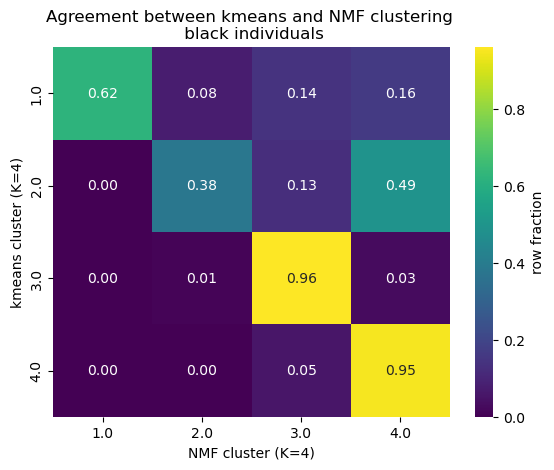

In [19]:
# Heatmap for black individuals
ax = sns.heatmap(
    pd.crosstab(main_black_md["ClusterK4_kmeans"], main_black_md["ClusterK4_NMF"], normalize="index"),
    annot=True, fmt=".2f", cmap="viridis", cbar_kws={"label": "row fraction"},
)
ax.set_xlabel("NMF cluster (K=4)")
ax.set_ylabel("kmeans cluster (K=4)")
ax.set_title("Agreement between kmeans and NMF clustering \n black individuals")

plt.savefig(f'{FIGS}/black_individuals_clustering_concordance.png')


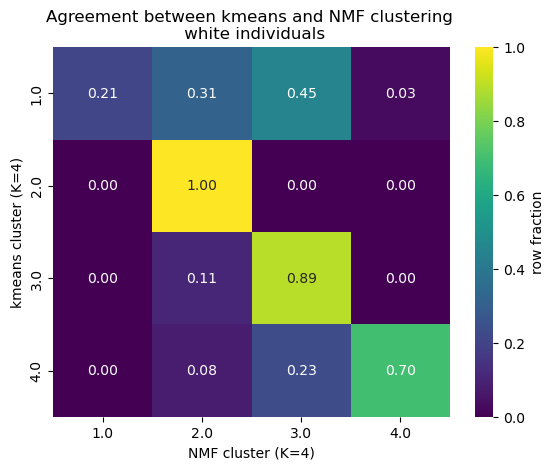

In [20]:
# Heatmap for white individuals
ax = sns.heatmap(
    pd.crosstab(main_white_md["ClusterK4_kmeans"], main_white_md["ClusterK4_NMF"], normalize="index"),
    annot=True, fmt=".2f", cmap="viridis", cbar_kws={"label": "row fraction"},
)
ax.set_xlabel("NMF cluster (K=4)")
ax.set_ylabel("kmeans cluster (K=4)")
ax.set_title("Agreement between kmeans and NMF clustering \n white individuals")

plt.savefig(f'{FIGS}/white_individuals_clustering_concordance.png')

### Thougths

K-means and NMF show only partial agreement in their cluster assignments, and the disagreement appears to be race-dependent. In white individuals the Proliferative subtype is stable while Mesenchymal is unstable, whereas in black individuals the pattern reverses: Mesenchymal is stable and Proliferative falls apart.

This suggests that subtype reproducibility itself is race-dependent, which is relevant when transferring a classifier trained on one group to another.

In [21]:
# Our sample ID names aren't the same between DGE and metadata. Let's add 'Sample_' to each ID in metadata. 
# And save filtered metadata

main_black_md['ID'] = 'Sample_' + main_black_md['ID'].astype(str)
main_white_md['ID'] = 'Sample_' + main_white_md['ID'].astype(str)

main_black_md.to_csv(f'{OUT}/black_metadata_cleaned.csv', sep=',', header=True, index=False)
main_white_md.to_csv(f'{OUT}/white_metadata_cleaned.csv', sep=',', header=True, index=False)